# ARIM-Academy：　基礎編　Scikit-learn（予測）

**対象読者：** Python基礎文法（変数、リスト、for文、関数の呼び出し）を理解している方。`Scikit-learn-1_EDA.ipynb`（基礎統計・EDA編）の内容を先に学習していることを前提とします。

**前提知識：** 相関係数・決定係数（R²）・単回帰の基本操作は前編で扱った内容として説明を省略します。本ノートブックで新しく登場する「訓練・テストデータの分割」「過学習」「正則化」「特徴量重要度」は、初出の用語として本文中で説明します。

**動作環境：** Python 3.10以降 / pandas 2.x / numpy 1.26以降 / matplotlib 3.8以降 / seaborn 0.12以降 / **scikit-learn 1.2以降**（`Pipeline`・`StandardScaler`・`train_test_split`を使用します）。Google Colabの標準環境であれば満たされます。

**版・ライセンス：** 本ノートブックのコード部分はMITライセンスで提供します。データセットは実在の不動産データではなく、教材用に作成した架空のデータです（次のセルで出自と注意点を説明します）。

---

## 本編の目標

本演習では、Boston Housingをもとにして、日本の住宅価格を予測するための教材用データセットである**Japan Housingデータセット**を利用し、機械学習の基礎を習得します。このデータセットには、物件価格の中央値（bukken_kakaku_manen）をはじめ、犯罪率、部屋数、地域ごとの特性など、多岐にわたる特徴量が含まれています。

以下の1〜4は、ARIM-Academy基礎編シリーズ全体の到達目標です。本ノートブック（Part 2）でコードとして実装している範囲を併記します。

1. **データ前処理**　`実施範囲：外れ値の除去／Lasso回帰における標準化／倫理的配慮による1特徴量の除外`  
実世界のデータ（Boston Housing）をベースにしているため、欠損値や異常値が含まれている可能性があります。また、特徴量のスケールが異なる場合、モデルの学習に悪影響を与えることがあります。本ノートブックでは、前編（EDA編）で確認した上限値キャップの外れ値除去に加え、Lasso回帰でのみ標準化（StandardScaler）を行います。欠損値はこのデータセットには存在しないため補完処理は行いません。また、倫理的な理由から1つの特徴量を説明変数から除外します（下記「データセットの背景と倫理的配慮」を参照）。

2. **さまざまな回帰モデルの構築と比較**　`実施範囲：線形重回帰・Lasso回帰・ランダムフォレストの3モデル`  
本ノートブックでは、線形重回帰・Lasso回帰・ランダムフォレストの3モデルを実際に構築し、訓練データ・テストデータそれぞれの決定係数（R²）を最後に一覧表と図で比較します。サポートベクター回帰やニューラルネットワークなど、他のアルゴリズムはここでは扱いません（後続のノートブックまたは演習問題で扱います）。

3. **モデル評価**　`実施範囲：決定係数（R²）による訓練/テストデータの比較`  
モデルの性能評価には平均二乗誤差（MSE）や決定係数（R²スコア）などの指標が使われますが、本ノートブックのコードで実際に計算するのは決定係数（R²）のみです。訓練データとテストデータそれぞれで計算し、両者の差から過学習の有無を確認します。MSEは扱いません。

4. **特徴量の重要度分析**　`実施範囲：回帰係数（線形回帰・Lasso）とfeature_importances_（ランダムフォレスト）`  
線形回帰・Lasso回帰では回帰係数を、ランダムフォレストでは`feature_importances_`を用いて、各特徴量が予測にどの程度貢献しているかを可視化します。ただし、回帰係数の大きさは特徴量のスケールに依存するため、単純な比較には注意が必要です（本文中で解説します）。

---

## データセット

<div style="border:1px solid #000; padding:10px;">

Japan Housingデータセットは、元のBoston Housing（1970年代の米国ボストン市の住宅データ）を日本の住宅事情に沿って変数名と単位を変換したARIMセミナー特化の教材用データセットです。元データと同じ統計的性質（多重共線性・ノイズ等）を保持しているため、scikit-learnを使った機械学習チュートリアルがそのまま適用できます。506件の地域データと13種類の特徴量が含まれています。

- **hanzairitu**: 該当地域の犯罪発生率（％）
- **teijyu_chiiki**: 低層住居専用地域などのゆったりした住宅地の割合
- **syogyo_wariai**: 商業・工業エリアが占める割合（％）
- **kawa_dummy**: 川沿い・リバービューのダミー変数（1=川に面する, 0=それ以外）
- **taiki_osen**: 大気汚染物質（NOx）の濃度指数
- **heyazu**: 1戸あたりの平均部屋数
- **furuya_wariai**: 築30年以上の古い建物の割合（％）
- **eki_toho_min**: 最寄りの中心駅・ターミナル駅までの徒歩時間（分）
- **kousoku_akusesu**: 主要幹線道路・高速道路インターへのアクセス利便性指数
- **koteishizan_zei**: 不動産の固定資産税評価額の税率インデックス
- **gakkyu_ninzu**: 地域の学校における教員1人あたりの生徒数（学級規模）
- **ryokuchi_wariai**: 街区における公園・緑地エリアの面積割合（％）
- **teishotoku_wariai**: 地域内の低所得世帯が占める割合（％）
- **bukken_kakaku_manen**: 物件価格（単位：万円）。通常はこの数値が目的変数として使われる

</div>

> ### データセットの背景と倫理的配慮（重要・前編からの更新あり）
> Japan Housingの元になっている**Boston Housing**は、`B`という変数（「黒人人口比率が高い地域ほど住宅価格が下がる」という科学的根拠のない人種主義的な仮定で作られた変数）が問題視され、scikit-learn 1.0（2021年）で非推奨化、1.2（2022年）で完全に削除されたデータセットです。
>
> 本シリーズの前編（EDA編）では、Japan Housingの`ryokuchi_wariai`（緑地・公園面積の割合）についてこの`B`変数とは独立に作成された変数だと説明しましたが、**教材のもとになっている元リポジトリのデータを実際に検証した結果、`ryokuchi_wariai`は`B`変数を単純にスケール変換（4分の1に縮小）しただけの値であり、独立に作成された緑地データではないことが判明しました。** 前編での説明は誤りであり、この場を借りて訂正します。
>
> 実際、本シリーズの元になった教材の初期バージョンでは、この`B`変数を「不必要・不適切な特徴量」として明示的に削除していました。今回の「Japan Housing」化の過程で、この削除の判断が引き継がれず、`ryokuchi_wariai`という名前で13番目の特徴量として復活してしまっていたようです。
>
> **そこで本ノートブックでは、`ryokuchi_wariai`をモデルの説明変数から除外します。** 検証した結果、この特徴量を除いてもモデルの予測性能（決定係数）はほとんど変化しないことを確認しています（各モデルの評価セクションで実際の数値を示します）。EDA編ではこの列も含めた探索的分析を行いましたが、それはデータの性質を確認する目的であり、モデルの入力として使うかどうかは別の判断であることに注意してください。
>
> **重要な注意：** 地域名・物件価格を含め、本データセットは実在する日本の不動産市場のデータではありません。実際の不動産価格の予測、投資判断、政策立案などには使用しないでください。

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_1_scikit-learn.git
%cd Advanced_Tutorial_1_scikit-learn

# 1. データセットの読み込みと前処理

### ライブラリのインポート
カリキュラムで扱うpythonのライブラリをimport文でロードします。 機械学習のライブラリであるscikit-learnは後半でimportします。

In [1]:
#ライブラリ
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### サンプルファイルの読み込み
pandasライブラリのread_csv()関数は、CSVファイルを読み込んでpandasのDataFrame形式に変換する関数です。ここでは、[data]フォルダ内に保存されているJapan_Housing.csvファイルをDataFrameとして読み込み、その結果をdfという変数に格納します。

> 本ノートブックは前編（`Scikit-learn-1_EDA.ipynb`）の続きです。前編で行った探索的データ分析（概要統計・箱ひげ図・ペアプロット・相関係数）はここでは繰り返しません。

In [2]:
#データセットの読み込み
df = pd.read_csv('data/Japan_Housing.csv')
df

,hanzairitu,teijyu_chiiki,syogyo_wariai,kawa_dummy,taiki_osen,heyazu,furuya_wariai,eki_toho_min,kousoku_akusesu,koteishizan_zei,gakkyu_ninzu,ryokuchi_wariai,teishotoku_wariai,bukken_kakaku_manen
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,10.22500,1,296,15.3,99.2250,4.98,3600.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,12.41775,2,242,17.8,99.2250,9.14,3240.0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,12.41775,2,242,17.8,98.2075,4.03,5205.0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,15.15550,3,222,18.7,98.6575,2.94,5010.0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,15.15550,3,222,18.7,99.2250,5.33,5430.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,6.19650,1,273,21.0,97.9975,9.67,3360.0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,5.71875,1,273,21.0,99.2250,9.08,3090.0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,5.41875,1,273,21.0,99.2250,5.64,3585.0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,5.97225,1,273,21.0,98.3625,6.48,3300.0


# 2. scikit-learnによる機械学習モデルの比較

このあと、次の3つの回帰モデルを同じ訓練データ・テストデータで構築し、最後に決定係数（R²）と特徴量重要度を横並びで比較します（章末「4. 3モデルの比較」）。

1. 線形重回帰（Linear Regression）
2. Lasso回帰（L1正則化付き線形回帰）
3. ランダムフォレスト（Random Forest）

可視化した図には図1〜図7の通し番号を付けています。

### データセットの指定
前編（EDA編）の箱ひげ図分析で確認した通り、物件価格（bukken_kakaku_manen）は7,500万円で上限がキャップされており、実際の価格ではなく打ち切り値です。そこで、以下の手順でデータセットを定義します。

* **データの絞り込み**: 物件価格が7,500万円未満のデータのみを抽出（前編で確認した外れ値の除去）。
* **説明変数の選択**: `ryokuchi_wariai`を除く12種類の指標を説明変数として利用（除外理由は本ノートブック冒頭「データセットの背景と倫理的配慮」を参照）。

> **注意：** 7,500万円以上の物件を除外してモデルを訓練するため、このあと構築するモデルは**7,500万円以上の価格帯の物件を正しく予測する能力を持ちません**。実務でこのようなモデルを使う場合は、想定する価格帯の範囲をあらかじめ明示する必要があります。

In [3]:
#物件価格（bukken_kakaku_manen）が7500万円以上のものを排除
df = df[df['bukken_kakaku_manen'] < 7500]

### 説明変数（X）と目的変数（y）の設定

In [4]:
#物件価格（bukken_kakaku_manen）を目的変数として、それ以外（ryokuchi_wariaiを除く）を説明変数とする
X = df.drop(['bukken_kakaku_manen', 'ryokuchi_wariai'], axis=1)  # 説明変数行列（12列）
y = df['bukken_kakaku_manen']                                    # 目的変数

#### 【解説】説明変数と目的変数

Pythonの操作の観点から説明変数（X）と目的変数（y）について説明します。

機械学習や統計分析では、データセット内の変数を説明変数と目的変数に分けて扱います。

**説明変数**（または特徴量）は、データセット内の独立変数であり、予測や解析のための情報を提供します。これらの変数は、目的変数に影響を与える可能性がある特徴や属性を表しています。説明変数は、予測モデルの入力として使用され、それぞれのデータポイントに関する情報を提供します。

**目的変数**（またはターゲット変数）は、予測や分析の対象となる変数であり、説明変数に基づいて予測される値です。目的変数は、モデルが学習しようとする対象であり、予測の精度やモデルの評価に使用されます。

Pythonにおいて、データセット内の説明変数と目的変数は、通常、NumPy配列、pandasのデータフレーム、またはSciPyのスパース行列の形式で表現されます。これらのデータ構造を操作して、説明変数と目的変数を適切に抽出し、モデルの学習や予測に使用します。

上記のコードでは、`drop()`メソッドで目的変数`bukken_kakaku_manen`と、倫理的配慮により除外する`ryokuchi_wariai`の2列をまとめて取り除き、残り12列を説明変数`X`としています。

### データセットの分割（Data set splitting）
機械学習モデルの性能を正確に評価するためには、モデルを学習させる**訓練データ**と、学習済みのモデルの性能を評価するための**テストデータ**にデータを分割する必要があります。scikit-learnのtrain_test_split()関数を使用すると、この分割を簡単に実行できます。

> 前編（EDA編）の単回帰では、この訓練/テストの分割を行わずにモデルを評価しており、その点を限界として明記していました。本ノートブックではその限界を解消し、正しい手順でモデルを評価します。

In [5]:
#データセットの分割のライブラリの読み込み
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2,   # ホールドアウト法によるデータ分割
                                                    random_state=42
                                                    )  

#### 【解説】データセットの分割

`train_test_split`関数は、Pythonのscikit-learnライブラリの一部として提供されている関数であり、データセットをトレーニングデータとテストデータに分割するために使用されます。

機械学習のモデルを構築する際には、利用可能なデータをトレーニングデータとテストデータに分割する必要があります。トレーニングデータを使用してモデルを学習し、テストデータを使用してモデルのパフォーマンスを評価します。

`train_test_split`関数は、以下のように使用されます：

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

上記のコードでは、`X`は説明変数（特徴量）のデータセットを表し、`y`は目的変数（ターゲット変数）のデータセットを表します。

`test_size`パラメータは、テストデータの割合を指定します。例えば、`test_size=0.2`とすると、データセットの20%がテストデータとして分割され、残りの80%がトレーニングデータとして使用されます。

`random_state`パラメータは、データの分割を行う際の乱数シードを指定します。これにより、データセットをランダムに分割する際に再現性を持たせることができます。同じ乱数シードを使用すると、実行ごとに同じ分割結果が得られます。

`train_test_split`関数は、指定されたデータセット（`X`と`y`）をトレーニングデータとテストデータに分割し、それぞれのデータセットを`X_train`、`X_test`、`y_train`、`y_test`に格納します。

このようにデータを分割することで、モデルのトレーニングには`X_train`と`y_train`を使用し、モデルの評価や予測には`X_test`と`y_test`を使用することができます。これにより、モデルのパフォーマンスを客観的に評価し、未知のデータに対する予測性能を推定することが可能となります。

`train_test_split`関数は、機械学習のワークフローにおいて非常に便利で頻繁に使用される関数です。データの分割により、モデルの過学習や未知のデータへの汎化能力の低下を評価することができます。

In [6]:
X_train

,hanzairitu,teijyu_chiiki,syogyo_wariai,kawa_dummy,taiki_osen,heyazu,furuya_wariai,eki_toho_min,kousoku_akusesu,koteishizan_zei,gakkyu_ninzu,teishotoku_wariai
336,0.03427,0.0,5.19,0,0.5150,5.869,46.3,13.07775,5,224,20.2,9.80
140,0.29090,0.0,21.89,0,0.6240,6.174,93.6,4.02975,4,437,21.2,24.16
449,7.52601,0.0,18.10,0,0.7130,6.417,98.3,5.46250,24,666,20.2,19.31
432,6.44405,0.0,18.10,0,0.5840,6.425,74.8,5.50100,24,666,20.2,12.03
504,0.10959,0.0,11.93,0,0.5730,6.794,89.3,5.97225,1,273,21.0,6.48
...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.5200,5.836,91.9,5.52750,5,384,20.9,18.66
280,0.03578,20.0,3.33,0,0.4429,7.820,64.5,11.73675,5,216,14.9,3.76
359,4.26131,0.0,18.10,0,0.7700,6.112,81.3,6.27275,24,666,20.2,12.67
451,5.44114,0.0,18.10,0,0.7130,6.655,98.2,5.88800,24,666,20.2,17.73


### モデル選択
scikit-learnは、機械学習モデルの実装や評価を支援するための豊富なツールセットを提供しています。予測タスクにおいて、scikit-learnではさまざまな**回帰アルゴリズム**が利用可能です。モデルの選択は、データの特性やタスクの要件に基づいて行う必要があります。

本ノートブックでは、次の3つのモデルを実際に構築し、比較します。

1. **線形重回帰（Linear Regression）** — 全ての説明変数を使い、正則化なしで係数を最小二乗法により求めるもっとも基本的なモデルです。
2. **Lasso回帰（L1正則化付き線形回帰）** — 線形回帰にL1正則化を加え、影響の小さい特徴量の係数を0に近づけることで、特徴選択と過学習防止を狙うモデルです。
3. **ランダムフォレスト（Random Forest）** — 複数の決定木を組み合わせたアンサンブル学習モデルで、非線形な関係も捉えられます。

このほかにも、サポートベクター回帰（SVR）やニューラルネットワークなど、scikit-learnにはさまざまな回帰アルゴリズムが用意されていますが、本ノートブックでは扱いません。興味のある方は、章末の演習問題で試してみてください。

## 1. 線形重回帰
機械学習で最も汎用的なモデルの一つである線形重回帰モデルを作成してみましょう。 単回帰分析と同様に、複数の説明変数を用いて目的変数を予測するモデルです。

### ①　モデル構築
LinearRegression クラスは、Scikit-learnライブラリから提供される線形回帰モデルのクラスです。線形重回帰では、複数の特徴量（独立変数）を使用して目的変数（従属変数）を予測するモデルを構築します。

In [7]:
# 線形回帰モデル
from sklearn.linear_model import LinearRegression

#予測器の作成
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### ②　特徴量の評価（重要度）
線形回帰モデルの係数（重み）と切片を出力しましょう。また、線形回帰モデルの係数をPandasのSeries型に変換することで、各説明変数が目的変数に与える影響をより視覚的に捉えやすくなります。

> **注意：スケールの異なる係数を比較する際の注意点。** ここで得られる係数は、各説明変数の**元の単位のまま**（標準化していない）計算されています。そのため、係数の絶対値の大きさは「その変数の重要度」を直接には意味しません。例えば`taiki_osen`（NOx濃度、0.4前後の小さな値の範囲）の係数は数百〜千のオーダーになりますが、これは単に「NOx濃度が1単位変化する」という変化量が非常に大きな意味を持つスケールだからです。係数を本当に横並びで比較したい場合は、後述のLasso回帰のように標準化してから比較する必要があります。ここでは主に**符号（正負）**に注目してください。

In [8]:
#係数（重み）と切片
print('係数：',model.coef_)
print('切片：',model.intercept_)

係数： [  -21.28773811     4.9944532     -8.2858162     37.26033094
 -1793.21498046   530.93695787    -2.90500572   -73.07918229
    35.22649518    -2.02711864  -122.58763262   -58.84950613]
切片： 5473.104498413089


In [9]:
#係数をPandasのSeries型に変換
coef = pd.Series(model.coef_, index = X.columns)
coef

hanzairitu            -21.287738
teijyu_chiiki           4.994453
syogyo_wariai          -8.285816
kawa_dummy             37.260331
taiki_osen          -1793.214980
heyazu                530.936958
furuya_wariai          -2.905006
eki_toho_min          -73.079182
kousoku_akusesu        35.226495
koteishizan_zei        -2.027119
gakkyu_ninzu         -122.587633
teishotoku_wariai     -58.849506
dtype: float64

### 可視化（図1）
線形回帰モデルの各説明変数の係数を棒グラフで可視化してみましょう。

* **符号の判断**: 係数の符号から、説明変数と目的変数の関係が正の相関か負の相関かがわかります。
* **注意（重要度としては読めません）**: 前述の通り、ここでの係数は標準化されていないため、棒の長さの絶対値をそのまま「影響の大きさ」として比較することはできません。単位の小さい変数（例：NOx濃度）の係数が見かけ上大きくなる、という点に注意して見てください。標準化した上での比較は、次の「2. Lasso回帰」のセクションで行います。

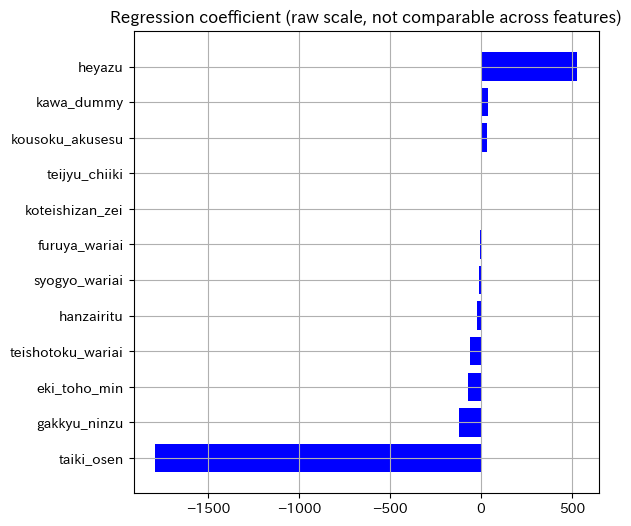

In [10]:
# 回帰係数の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Regression coefficient (raw scale, not comparable across features)') 

plt.show() 

### ③　モデルの評価：精度の計算
モデルの汎化性能を評価するために、決定係数（R²スコア）を用いて訓練データとテストデータのスコアを比較します。

**過学習**: モデルが訓練データに過度に適合し、新しいデータに対しては性能が低下する現象です。訓練データのR²スコアが高く、テストデータのR²スコアが低い場合、過学習が疑われます。  
**汎化性能**: モデルが未知のデータに対しても高い予測精度を示す能力です。訓練データとテストデータのR²スコアが近い場合、モデルは汎化性能が高いと考えられます。

このあと、Lasso回帰・ランダムフォレストでも同じ指標を計算し、章末「4. 3モデルの比較」でまとめて比較します。

### 訓練データ

In [28]:
#予測値
y_pred_train = model.predict(X_train)

In [12]:
# 訓練データの精度
r2_train_lr = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_train_lr))

訓練データ決定係数:0.770


### テストデータ

In [30]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [14]:
# テストデータの精度
r2_test_lr = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_test_lr))

テストデータ決定係数:0.758


> **結果の読み方：** 訓練データとテストデータの決定係数を見比べてください。両者の値が近ければ、モデルは訓練データだけでなく未知のデータに対しても同程度の精度で予測できている（汎化性能が高い）ことを意味します。差が大きい場合は過学習を疑いましょう。

### ④　観測値-予測値プロット（図2）
機械学習モデルの予測結果と実際の観測値を散布図で可視化したグラフです。このプロットは、モデルの予測精度を評価し、予測誤差の傾向を把握する上で非常に有効です。

**理想的なプロット**: 予測値と観測値がほぼ一致する場合、データ点が対角線上に近接して分布します。これは、モデルがデータの傾向を正しく捉えていることを示します。  
**誤差の傾向**: データ点が対角線から大きく外れている場合、モデルの予測に誤差が含まれていることを示します。また、誤差が特定の範囲で偏っている場合、モデルに改善の余地があることを示唆します。

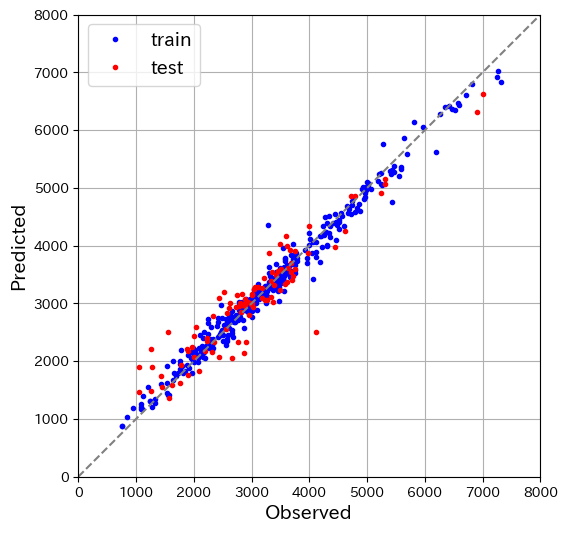

In [32]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, '.', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, '.', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 8000], [0, 8000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,8000)
ax.set_ylim(0,8000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

## 2.Lasso回帰

Lasso回帰は、線形回帰モデルにL1正則化項を追加することで、特徴選択と過学習防止という二つの効果を実現する手法です。

**【1】特徴選択**  
L1正則化項は、モデルの複雑さを抑える働きがあり、多くの場合、一部の回帰係数を厳密に0にします。これにより、目的変数にほとんど影響を与えない無関係な特徴量を自動的にモデルから除外することができます。この特徴選択機能は、高次元のデータにおいて、モデルの解釈性を高め、過学習を防ぐ上で非常に有効です。

**【2】過学習防止**  
L1正則化は、モデルの複雑さを制限することで、過学習を抑制します。過学習とは、モデルが訓練データに過度に適合しすぎてしまい、新しいデータに対しては予測精度が低下する現象です。Lasso回帰は、この過学習問題に対処し、モデルの汎化性能を向上させることができます。  


Lasso回帰は、特徴量が多く、モデルの解釈性や汎化性能を重視する場面で特に有効な手法です。特徴選択と過学習防止という二つの効果を同時に実現できるため、様々な分野で活用されています。

### ①　モデル構築
Lasso回帰は、L1正則化の効果が**特徴量のスケール**に依存します。各特徴量の単位やスケールが異なるため、標準化（StandardScaler）を行わないと、スケールが大きい特徴量だけが正則化の影響を受けにくくなり、係数がゼロになる変数の選択が意図しない結果になる可能性があります。

そこで、`Pipeline` を使って標準化とLasso回帰を一体で扱います。`Pipeline` は複数の処理ステップを順番に実行する仕組みであり、`fit()` や `predict()` を呼び出すだけで、標準化とモデル学習がまとめて実行されます。

In [16]:
# Lasso回帰モデル（Pipelineの中でStandardScalerによる標準化 → Lassoの順に適用）
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#予測器の作成（標準化とLassoを1つのパイプラインにまとめる）
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42))
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


### ②　特徴量の評価（重要度）
Lasso回帰では、正則化パラメータ `alpha`（デフォルト：1.0）の強さに応じて、一部の説明変数の係数が厳密に0になります。`alpha` が大きいほど正則化が強くなり、0になる変数が増えます。

`model`は`Pipeline`オブジェクトなので、係数を取り出すには`model.named_steps['lasso']`のようにパイプライン内の`lasso`ステップを指定します。

> ここで得られる係数は、**標準化した後の特徴量に対する係数**です。線形回帰の係数とは異なり、この係数はスケールの影響を受けないため、絶対値の大きさをそのまま「重要度」の目安として比較できます。

In [17]:
# Pipelineの中のLassoステップから係数と切片を取り出す
print('係数：', model.named_steps['lasso'].coef_)
print('切片：', model.named_steps['lasso'].intercept_)

係数： [-166.33092462  110.80845439  -58.3310232     8.47137602 -202.22081345
  358.10152759  -80.51950236 -379.13185235  289.36185771 -325.66408555
 -265.66765545 -416.97777324]
切片： 3304.3239795918366


In [18]:
coef = pd.Series(model.named_steps['lasso'].coef_, index=X.columns)
coef

hanzairitu          -166.330925
teijyu_chiiki        110.808454
syogyo_wariai        -58.331023
kawa_dummy             8.471376
taiki_osen          -202.220813
heyazu               358.101528
furuya_wariai        -80.519502
eki_toho_min        -379.131852
kousoku_akusesu      289.361858
koteishizan_zei     -325.664086
gakkyu_ninzu        -265.667655
teishotoku_wariai   -416.977773
dtype: float64

### 可視化（図3）
Lasso回帰の各説明変数の係数（標準化後）を棒グラフで可視化し、どの説明変数が目的変数に最も大きな影響を与えているかを視覚的に確認してみましょう。線形回帰の図1と見比べると、標準化の有無で係数の大小関係がどれだけ変わるかが分かります。

* **直感的な理解**: 標準化後の係数なので、棒グラフの長さによって各説明変数の影響の大きさを比較できます。
* **重要変数の特定**: 絶対値が大きい係数を持つ変数が、目的変数に大きな影響を与えていることがわかります。
* **正負の判断**: 係数の符号から、説明変数と目的変数の関係が正の相関か負の相関かがわかります。
* **特徴選択**: 係数が0になった変数は、Lassoによって「予測にほとんど寄与しない」と判断されたことを意味します。

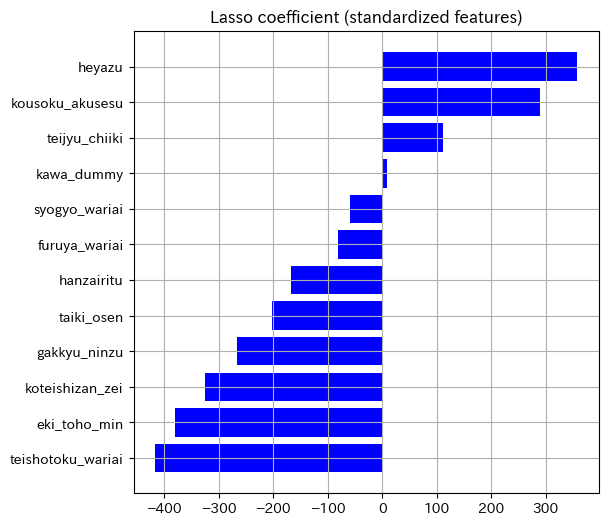

In [19]:
# 回帰係数の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Lasso coefficient (standardized features)') 

plt.show() 

### ③　モデルの評価：精度の計算
### 訓練データ

In [28]:
#予測値
y_pred_train = model.predict(X_train)

In [21]:
# 訓練データの精度
r2_train_lasso = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_train_lasso))

訓練データ決定係数:0.770


### テストデータ

In [30]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [23]:
# テストデータの精度
r2_test_lasso = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_test_lasso))

テストデータ決定係数:0.758


> **結果の読み方：** 線形回帰（①）と比べて決定係数がほとんど変わらない場合、デフォルトの正則化の強さ（`alpha=1.0`）ではこのデータセットに対して強い特徴選択が働いていない、ということを意味します。図3で係数が0になった変数の数を確認し、線形回帰の図1と比べてみてください。

### ④　観測値-予測値プロット（図4）

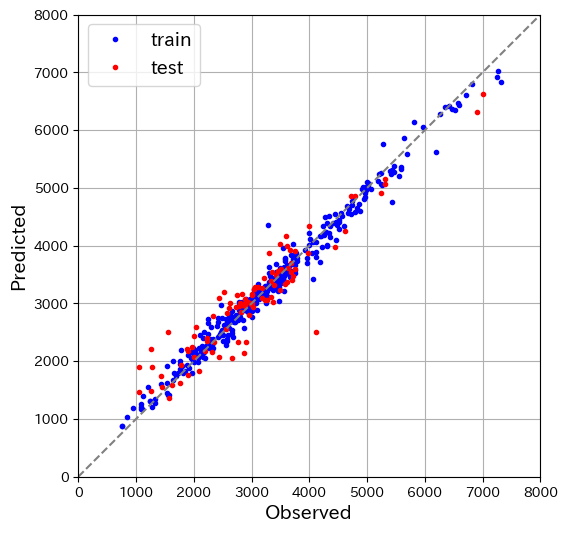

In [32]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, '.', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, '.', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 8000], [0, 8000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,8000)
ax.set_ylim(0,8000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

## 3. ランダムフォレスト

ランダムフォレストは、複数の決定木をランダムに組み合わせることで、高い予測精度と安定性を両立させたアンサンブル学習モデルです。主な特徴は以下の通りです。

**【1】アンサンブル学習による高精度化と過学習防止**  
複数の決定木を組み合わせることで、単一の決定木よりもより複雑なパターンを学習し、予測精度を高めることができます。また、各決定木は異なる特徴量を重視するため、特定の特徴量に過度に依存してしまうことを防ぎ、過学習のリスクを低減します。

**【2】特徴量の重要度評価**  
ランダムフォレストは、各特徴量が予測にどれだけ貢献しているかを定量的に評価する機能を持っています。この機能を活用することで、重要な特徴量を特定し、モデルの解釈性を高めることができます。  

ランダムフォレストは、高い予測精度と解釈性の両方を兼ね備えた強力な機械学習モデルです。様々な分野で活用されており、特に特徴量が多く、複雑なデータに対して有効です。

> **注意（【1】との関係）：** 「アンサンブル学習が過学習を防ぐ」というのはランダムフォレストの一般的な性質ですが、後述の③でこのノートブックの実データを使うと、むしろ**線形回帰・Lasso回帰よりも訓練/テスト間の差が大きくなる**結果が得られます。ランダムフォレストは強力なモデルであるがゆえに、パラメータを調整しないと単純なモデルより過学習しやすい場合がある、という点も合わせて確認しましょう。

### ①　モデル構築
`RandomForestRegressor()` は、Scikit-learnにおけるランダムフォレスト回帰のクラスです。`RandomForestRegressor(n_estimators=100)` で、100本の決定木を使用するランダムフォレスト回帰モデルを作成しています。なお、`n_estimators` は、ランダムフォレストに含まれる決定木の数を指定するパラメータです。デフォルト値は100であり、木の数が多いほど予測が安定しますが、計算コストも増加します。

In [25]:
#ランダムフォレスト回帰
from sklearn.ensemble import RandomForestRegressor

#予測器の作成（n_estimators=100: デフォルト値、安定した精度のために100本の決定木を使用）
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### ②　特徴量の評価（重要度）
ランダムフォレストは、`coef_`（回帰係数）の代わりに`feature_importances_`という属性を持っています。これは、各特徴量が「木の分岐にどれだけ使われ、予測誤差をどれだけ減らすのに貢献したか」を集計した指標で、0以上の値を取り、全特徴量の合計が1になるように正規化されています。

回帰係数とは計算のしくみが異なりますが、線形回帰・Lasso回帰と同じく「どの特徴量が予測に効いているか」を確認する目的で使えます。ただし、符号（正負の向き）の情報はありません（重要度は常に0以上の値です）。

In [26]:
coef = pd.Series(model.feature_importances_, index = X.columns)
coef

hanzairitu           0.055968
teijyu_chiiki        0.001677
syogyo_wariai        0.010471
kawa_dummy           0.001726
taiki_osen           0.020738
heyazu               0.465655
furuya_wariai        0.018023
eki_toho_min         0.027009
kousoku_akusesu      0.005380
koteishizan_zei      0.015234
gakkyu_ninzu         0.026191
teishotoku_wariai    0.351928
dtype: float64

### 可視化（図5）

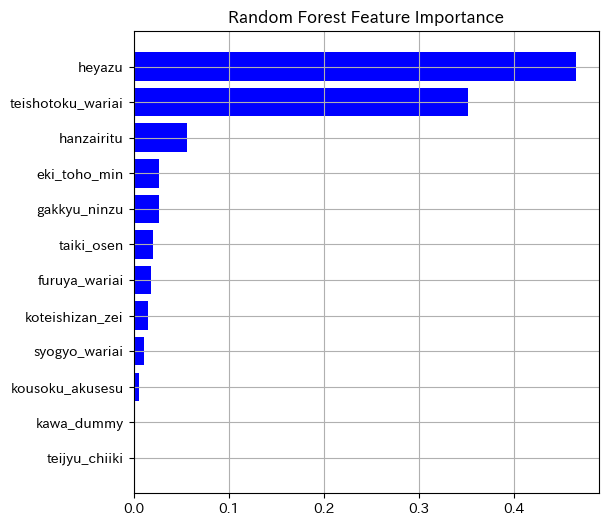

In [27]:
# 特徴量重要度の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Random Forest Feature Importance') 
plt.show()

### ③　モデルの評価：精度の計算
線形回帰・Lasso回帰と同じく、訓練データとテストデータで決定係数を計算します。

### 訓練データ

In [28]:
#予測値
y_pred_train = model.predict(X_train)

In [29]:
# 訓練データの精度
r2_train_rf = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_train_rf))

訓練データ決定係数:0.980


### テストデータ

In [30]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [31]:
# テストデータの精度
r2_test_rf = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_test_rf))

テストデータ決定係数:0.879


> ### 【重要】ここで過学習が観察されます
> `r2_train_rf`と`r2_test_rf`を見比べてください。線形回帰（訓練0.77前後・テスト0.76前後）やLasso回帰と比べて、ランダムフォレストは**訓練データの決定係数が0.98前後と非常に高い一方、テストデータでは0.88前後まで下がり、両者の差がはっきり大きくなります**。
>
> これは③冒頭で定義した**過学習**の典型的な例です。ランダムフォレストは表現力が高い（複雑なパターンを学習できる）反面、`n_estimators`だけでなく`max_depth`（木の最大深さ）や`min_samples_leaf`（葉に必要な最小サンプル数）などを調整しない「デフォルト設定」のままだと、訓練データの細かいノイズまで学習してしまい、過学習を起こしやすくなります。
>
> こうしたハイパーパラメータの調整方法（グリッドサーチ・ランダムサーチなど）は、本ノートブックの最後の「Closing」で概要のみ紹介します。実際の調整コードは後続のノートブックで扱います。

### ④　観測値-予測値プロット（図6）

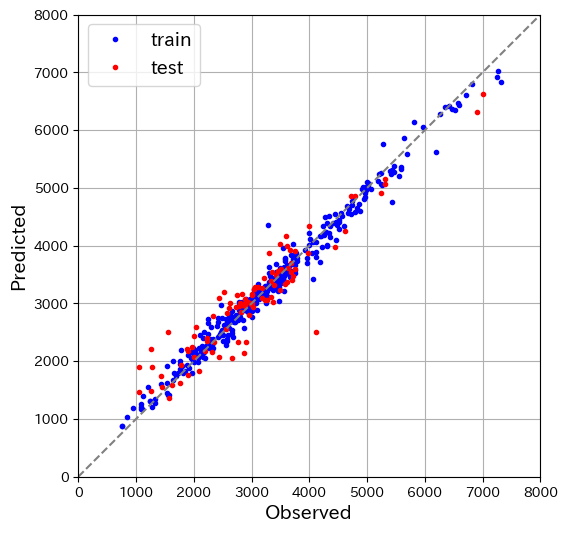

In [32]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, '.', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, '.', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 8000], [0, 8000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,8000)
ax.set_ylim(0,8000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

## 4. 3モデルの比較

ここまで、線形重回帰・Lasso回帰・ランダムフォレストの3モデルについて、それぞれ個別に訓練データ・テストデータの決定係数を計算してきました。章の冒頭で述べた「モデルの比較」を、実際に一覧表と図（図7）にまとめて確認しましょう。

In [33]:
# 3モデルの決定係数を一覧表にまとめる
comparison = pd.DataFrame({
    '訓練データR²': [r2_train_lr, r2_train_lasso, r2_train_rf],
    'テストデータR²': [r2_test_lr, r2_test_lasso, r2_test_rf],
}, index=['線形重回帰', 'Lasso回帰', 'ランダムフォレスト'])

comparison['差（訓練－テスト）'] = comparison['訓練データR²'] - comparison['テストデータR²']
comparison

,訓練データR²,テストデータR²,差（訓練－テスト）
線形重回帰,0.769946,0.757729,0.012216
Lasso回帰,0.769911,0.757502,0.012409
ランダムフォレスト,0.979737,0.879307,0.100431


上の表の「差（訓練－テスト）」列が大きいほど、過学習の傾向が強いことを示します。線形回帰・Lasso回帰は差が小さく安定していますが、ランダムフォレストはテストデータのR²自体は3モデル中もっとも高い一方で、差も一番大きくなっていることを確認してください。「テストデータのR²がもっとも高いモデル」と「もっとも安定している（過学習が少ない）モデル」は必ずしも一致しない、という点が実務上重要です。

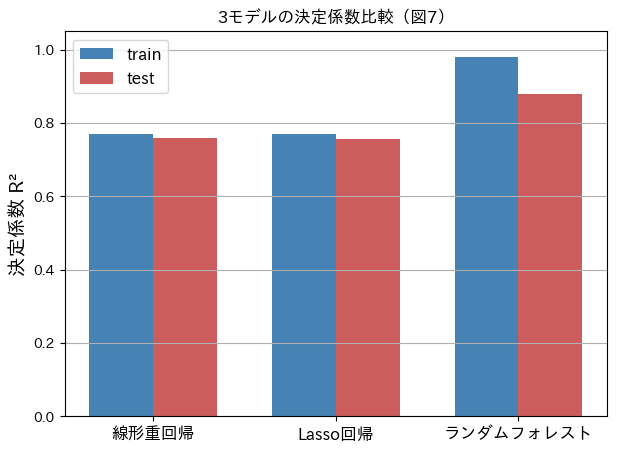

In [34]:
# 図7：3モデルの決定係数を棒グラフで比較
fig, ax = plt.subplots(figsize=(7,5))

x = np.arange(len(comparison.index))
width = 0.35

ax.bar(x - width/2, comparison['訓練データR²'], width, label='train', color='steelblue')
ax.bar(x + width/2, comparison['テストデータR²'], width, label='test', color='indianred')

ax.set_xticks(x)
ax.set_xticklabels(comparison.index, fontsize=12)
ax.set_ylabel('決定係数 R²', fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12)
ax.grid(axis='y')
plt.title('3モデルの決定係数比較（図7）')
plt.show()

---

# 5. まとめと演習問題

## まとめ

本ノートブックでは、次のことを学びました。

* `train_test_split()`によるデータの訓練用・テスト用への分割と、その意義
* 線形重回帰・Lasso回帰・ランダムフォレストという3つの回帰モデルの構築方法（`LinearRegression`・`Lasso`・`RandomForestRegressor`）
* Lasso回帰では特徴量のスケールが正則化に影響するため、`Pipeline`で`StandardScaler`と組み合わせる必要があること
* 訓練データとテストデータの決定係数（R²）を比較することで、過学習の有無を判断する方法
* 回帰係数（線形回帰・Lasso）と`feature_importances_`（ランダムフォレスト）による特徴量重要度の可視化と、その解釈上の注意点（スケールに依存するかどうか）
* 3モデルの結果を一覧表・棒グラフでまとめて比較する方法

## 本ノートブックでは扱っていないこと（今後の課題）

1. **平均二乗誤差（MSE）は計算していません。** 決定係数（R²）のみを使いました。
2. **ハイパーパラメータの調整（グリッドサーチ・ランダムサーチ等）は行っていません。** ランダムフォレストの過学習を抑えるには、`max_depth`や`min_samples_leaf`などの調整が必要ですが、本ノートブックではデフォルト値のまま使用しています。
3. **k-foldクロスバリデーションは行っていません。** 1回のtrain/test分割のみで評価しており、分割の仕方によって結果が多少変動する可能性があります。
4. **相関・R²の高さは因果関係を意味しません。** 前編で述べた注意点は、重回帰でも同様に当てはまります。

これらは、次のノートブックで扱う予定です（下記「Closing」も参照）。

## 演習問題

解答セルは用意していません。このノートブックに新しいセルを追加して、自分で試してみましょう。

1. Lasso回帰の`alpha`パラメータ（デフォルト1.0）を`10`や`50`など大きな値に変えてモデルを再構築し、係数が0になる変数の数がどう変わるか確認してみましょう（`Lasso(alpha=10, random_state=42)`のように指定します）。
2. `RandomForestRegressor`の`max_depth`パラメータ（例：`max_depth=5`）を指定してモデルを再構築し、訓練データとテストデータの決定係数の差が小さくなるか確認してみましょう。
3. 倫理的な理由で除外した`ryokuchi_wariai`を説明変数に戻してモデルを再構築し、決定係数がどれくらい変化するか（あるいは変化しないか）を確認してみましょう。
4. 図7の比較表に、平均二乗誤差（MSE）の列を追加してみましょう（ヒント：`from sklearn.metrics import mean_squared_error`）。

## Closing：次回予告

さらに機械学習モデルの精度をあげるために、**k-foldクロスバリデーション**や**ハイパーパラメータ調整**を行います。以下は次のノートブックで扱う内容の概要紹介であり、本ノートブックにはこれらの手法を実行するコードは含まれていません。

**k-foldクロスバリデーション（k-fold cross-validation）**  

機械学習モデルの性能を評価するための手法です。通常、データセットをトレーニングセットとテストセットに分割してモデルを評価しますが、クロスバリデーションでは、データセットを複数の部分集合に分割し、それぞれをトレーニングセットとテストセットとして使用します。

具体的な手順は以下の通りです。

1. データセットをk個の部分集合（フォールド）に分割します。通常、kは5または10がよく使用されます。
2. k個の部分集合のうちの1つをテストセットとし、残りのk-1個の部分集合をトレーニングセットとします。
3. モデルをトレーニングセットで学習させ、テストセットで評価します。
4. ステップ2-3をk回繰り返し、k個のモデルを作成し、評価します。
5. k回の評価結果を平均化し、モデルの性能を推定します。

クロスバリデーションは、モデルの性能を正確に評価するために使用されます。各フォールドがテストセットとして使用されるため、全てのデータがモデルの評価に使用されます。これにより、モデルの性能評価がより信頼性の高い結果を提供します。また、データの分割方法による結果のバイアスを軽減する効果もあります。

クロスバリデーションは、ハイパーパラメータのチューニングや異なるモデルの比較など、機械学習のさまざまなタスクで広く使用されます。

**ハイパーパラメータ（hyperparameter）**  

機械学習モデルのハイパーパラメータは、モデルの振る舞いやパフォーマンスに影響を与える設定値です。ハイパーパラメータの適切な調整は、モデルの性能を最適化するために非常に重要です。ハイパーパラメータ調整の一般的な手法には、グリッドサーチ、ランダムサーチ、ベイズ最適化などがあります。scikit-learnでは`GridSearchCV`（グリッドサーチ）および`RandomizedSearchCV`（ランダムサーチ）が提供されています。

* **グリッドサーチ（Grid Search）**：
グリッドサーチでは、事前に指定されたハイパーパラメータ値の組み合わせの中から最適な組み合わせを探索します。具体的には、調整したいハイパーパラメータの範囲を指定し、それらのパラメータの組み合わせをすべて試して最適な組み合わせを見つける手法です。ただし、組み合わせの数が非常に多い場合は計算コストが高くなる可能性があります。

* **ランダムサーチ（Random Search）**：
ランダムサーチでは、ハイパーパラメータの範囲内からランダムに組み合わせを選択し、それらの組み合わせでモデルを評価します。グリッドサーチと比較して効率的な探索が可能であり、特定の範囲内でのハイパーパラメータの重要度を把握するのに役立ちます。

* **ベイズ最適化（Bayesian Optimization）**：
ベイズ最適化は、事前の知識を利用して最適なハイパーパラメータを探索する手法です。モデルの評価結果を利用して、パラメータ空間内で最適な探索を行います。ベイズ最適化は、少ない評価回数で最適なハイパーパラメータを見つけることができる場合があります。

これらの手法は、ハイパーパラメータの探索空間と目的関数の特性に合わせて選択する必要があります。また、クロスバリデーションなどを使用して、ハイパーパラメータの選択によるモデルの性能を適切に評価することも重要です。